# Quantum Gates and Spinor Visualization

This notebook demonstrates how standard 1-qubit quantum gates transform spinor states using the hyperchord representation.

## Quantum Gates as Unitary Transformations

A quantum gate $U$ acting on a qubit state $|\psi\rangle$ produces a new state:
$$|\psi'\rangle = U|\psi\rangle$$

Since qubits are spinors, we can visualize these transformations using our hyperchord representation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import ipywidgets as widgets
from IPython.display import display, clear_output, Markdown

# Import spinor visualization
import sys
sys.path.insert(0, '..')
from spinor_viz import Spinor, plot_spinor_3d, plot_spinor_2d
from spinor_viz.core import pauli, normalize

%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 5]


## Standard 1-Qubit Quantum Gates

### Pauli Gates

In [2]:
# Define standard quantum gates
def identity_gate():
    """Identity gate I"""
    return np.array([[1, 0], [0, 1]], dtype=complex)

def pauli_x():
    """Pauli-X gate (NOT gate, bit-flip)"""
    return np.array([[0, 1], [1, 0]], dtype=complex)

def pauli_y():
    """Pauli-Y gate"""
    return np.array([[0, -1j], [1j, 0]], dtype=complex)

def pauli_z():
    """Pauli-Z gate (phase-flip)"""
    return np.array([[1, 0], [0, -1]], dtype=complex)

def hadamard():
    """Hadamard gate H"""
    return np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)

def phase_s():
    """S gate (√Z, phase gate)"""
    return np.array([[1, 0], [0, 1j]], dtype=complex)

def phase_s_dag():
    """S† gate (S-dagger)"""
    return np.array([[1, 0], [0, -1j]], dtype=complex)

def t_gate():
    """T gate (π/8 gate, √S)"""
    return np.array([[1, 0], [0, np.exp(1j * np.pi / 4)]], dtype=complex)

def t_gate_dag():
    """T† gate (T-dagger)"""
    return np.array([[1, 0], [0, np.exp(-1j * np.pi / 4)]], dtype=complex)

def rx_gate(theta):
    """Rotation around X-axis by angle theta"""
    return np.array([
        [np.cos(theta/2), -1j * np.sin(theta/2)],
        [-1j * np.sin(theta/2), np.cos(theta/2)]
    ], dtype=complex)

def ry_gate(theta):
    """Rotation around Y-axis by angle theta"""
    return np.array([
        [np.cos(theta/2), -np.sin(theta/2)],
        [np.sin(theta/2), np.cos(theta/2)]
    ], dtype=complex)

def rz_gate(theta):
    """Rotation around Z-axis by angle theta"""
    return np.array([
        [np.exp(-1j * theta / 2), 0],
        [0, np.exp(1j * theta / 2)]
    ], dtype=complex)

# Dictionary of gates with their names and descriptions
QUANTUM_GATES = {
    'I (Identity)': (identity_gate, 'Identity: leaves state unchanged'),
    'X (Pauli-X)': (pauli_x, 'Bit-flip: |0⟩↔|1⟩'),
    'Y (Pauli-Y)': (pauli_y, 'Bit+phase flip: |0⟩→i|1⟩, |1⟩→-i|0⟩'),
    'Z (Pauli-Z)': (pauli_z, 'Phase-flip: |1⟩→-|1⟩'),
    'H (Hadamard)': (hadamard, 'Creates superposition: |0⟩→|+⟩, |1⟩→|-⟩'),
    'S (Phase)': (phase_s, 'Quarter turn: |1⟩→i|1⟩'),
    'S† (S-dagger)': (phase_s_dag, 'Inverse quarter turn: |1⟩→-i|1⟩'),
    'T (π/8)': (t_gate, 'Eighth turn: |1⟩→e^(iπ/4)|1⟩'),
    'T† (T-dagger)': (t_gate_dag, 'Inverse eighth turn'),
}

print("Standard 1-qubit quantum gates loaded!")
print("\nGate matrices:")
for name, (gate_fn, desc) in list(QUANTUM_GATES.items())[:5]:
    print(f"\n{name}:")
    print(gate_fn())


Standard 1-qubit quantum gates loaded!

Gate matrices:

I (Identity):
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

X (Pauli-X):
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

Y (Pauli-Y):
[[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]

Z (Pauli-Z):
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]

H (Hadamard):
[[ 0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j -0.70710678+0.j]]


## Visualizing Gate Actions

Let's see how each gate transforms the basis states $|0\rangle$ (spin-up) and $|1\rangle$ (spin-down).

X gate on |0⟩ state:
Expected: |0⟩ → |1⟩


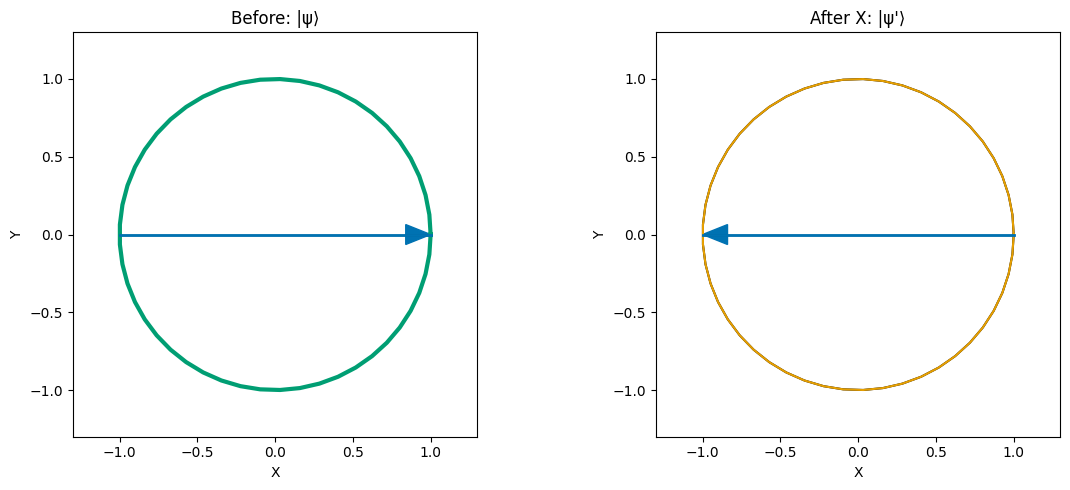


Initial: [1.+0.j 0.+0.j]
Final: [0.+0.j 1.+0.j]


In [3]:
def apply_gate_and_plot(gate_matrix, initial_spinor, gate_name="Gate", ax_before=None, ax_after=None):
    """
    Apply a quantum gate to a spinor and plot before/after states (2D top view).

    Parameters
    ----------
    gate_matrix : np.ndarray
        2x2 unitary gate matrix
    initial_spinor : Spinor
        Initial spinor state
    gate_name : str
        Name of the gate for title
    ax_before, ax_after : matplotlib axes
        Axes for before and after plots
    """
    # Get initial state vector
    initial_vec = initial_spinor.components

    # Apply gate
    final_vec = gate_matrix @ initial_vec
    final_spinor = Spinor(final_vec)

    # Plot
    if ax_before is None or ax_after is None:
        fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(12, 5))

    plot_spinor_2d(initial_spinor, ax=ax_before)
    ax_before.set_title(f'Before: |ψ⟩', fontsize=12)

    plot_spinor_2d(final_spinor, ax=ax_after)
    ax_after.set_title(f'After {gate_name}: |ψ\'⟩', fontsize=12)

    return final_spinor

# Example: X gate on |0⟩
print("X gate on |0⟩ state:")
print("Expected: |0⟩ → |1⟩")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

spin_up = Spinor.from_angles(0, 0)  # |0⟩
result = apply_gate_and_plot(pauli_x(), spin_up, "X", ax1, ax2)
plt.tight_layout()
plt.show()

print(f"\nInitial: {spin_up.components}")
print(f"Final: {result.components}")


### Hadamard Gate: Creating Superposition

Hadamard gate on |0⟩ state:
Expected: |0⟩ → |+⟩ = (|0⟩ + |1⟩)/√2


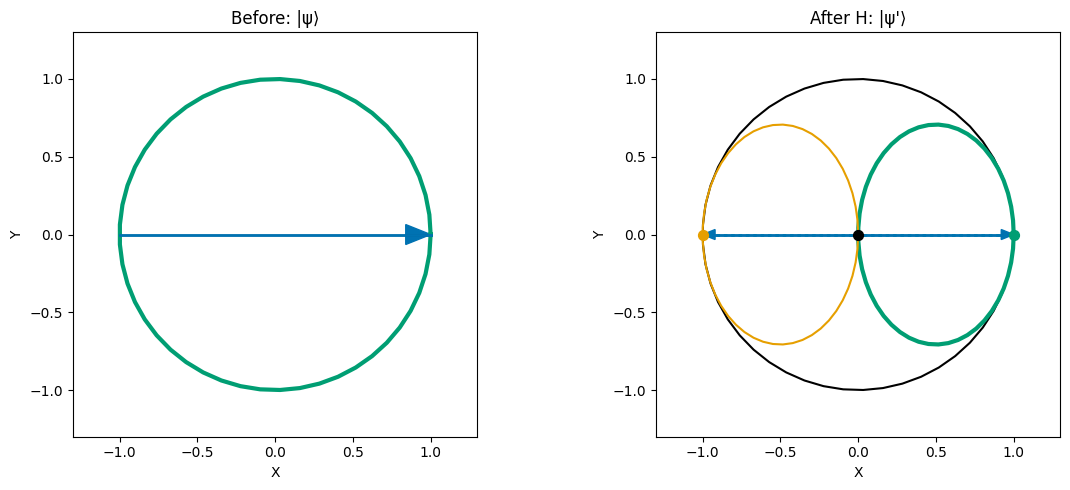


Initial: [1.+0.j 0.+0.j]
Final: [0.70710678+0.j 0.70710678+0.j]
Expected |+⟩: [0.7071, 0.7071]


In [4]:
# Hadamard on |0⟩ creates |+⟩ = (|0⟩ + |1⟩)/√2
print("Hadamard gate on |0⟩ state:")
print("Expected: |0⟩ → |+⟩ = (|0⟩ + |1⟩)/√2")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

spin_up = Spinor.from_angles(0, 0)  # |0⟩
result = apply_gate_and_plot(hadamard(), spin_up, "H", ax1, ax2)
plt.tight_layout()
plt.show()

print(f"\nInitial: {spin_up.components}")
print(f"Final: {result.components}")
print(f"Expected |+⟩: [{1/np.sqrt(2):.4f}, {1/np.sqrt(2):.4f}]")


### Comparing All Pauli Gates on |+⟩ State

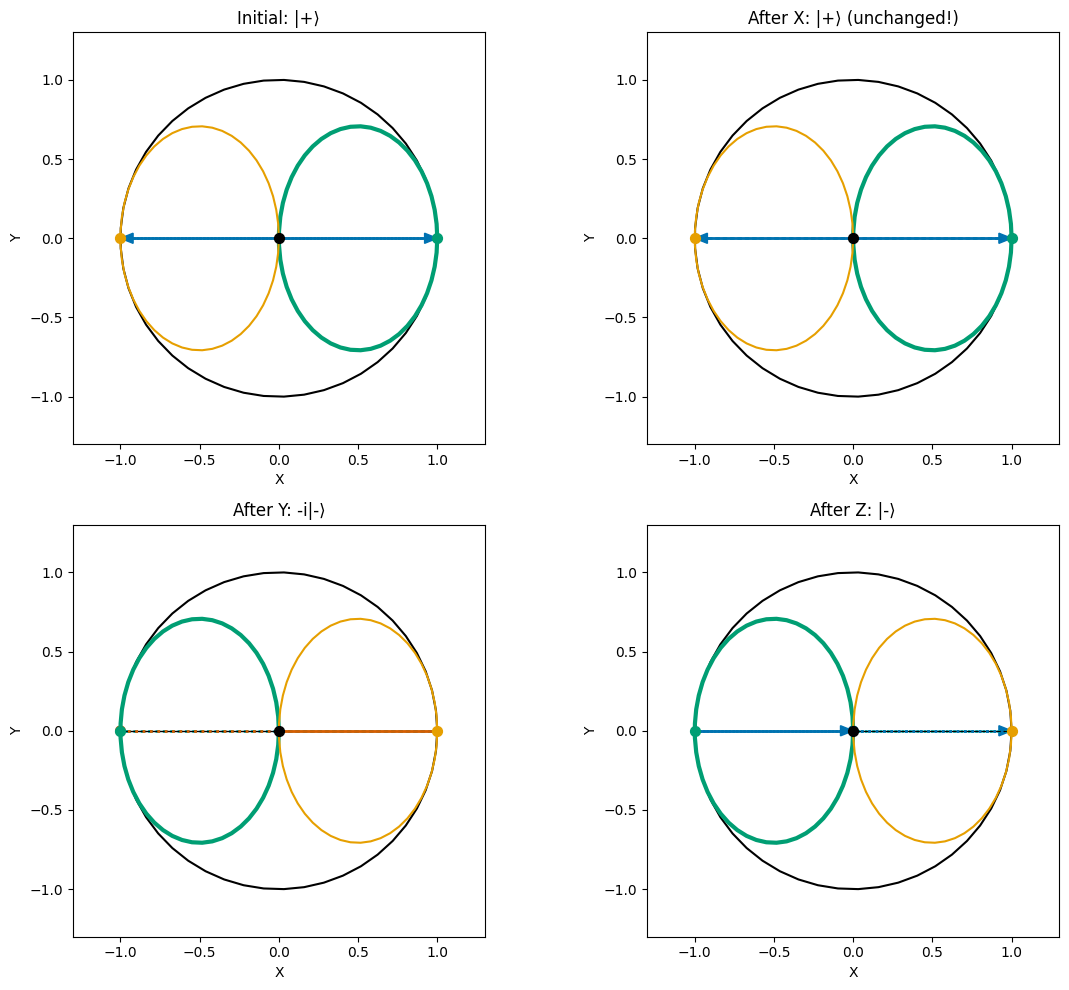

Note: X leaves |+⟩ unchanged (|+⟩ is an eigenstate of X)
      Z flips |+⟩ to |-⟩


In [5]:
# Start with |+⟩ state and show effect of X, Y, Z
plus_state = Spinor(np.array([1, 1], dtype=complex) / np.sqrt(2))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Original state
plot_spinor_2d(plus_state, ax=axes[0, 0])
axes[0, 0].set_title('Initial: |+⟩', fontsize=12)

# X gate
x_result = Spinor(pauli_x() @ plus_state.components)
plot_spinor_2d(x_result, ax=axes[0, 1])
axes[0, 1].set_title('After X: |+⟩ (unchanged!)', fontsize=12)

# Y gate
y_result = Spinor(pauli_y() @ plus_state.components)
plot_spinor_2d(y_result, ax=axes[1, 0])
axes[1, 0].set_title('After Y: -i|-⟩', fontsize=12)

# Z gate
z_result = Spinor(pauli_z() @ plus_state.components)
plot_spinor_2d(z_result, ax=axes[1, 1])
axes[1, 1].set_title('After Z: |-⟩', fontsize=12)

plt.tight_layout()
plt.show()

print("Note: X leaves |+⟩ unchanged (|+⟩ is an eigenstate of X)")
print("      Z flips |+⟩ to |-⟩")


## Interactive Quantum Gate Explorer

Use the widgets below to:
- Select an **initial state** (predefined or custom angles)
- Choose a **quantum gate** from the dropdown, or define a **custom 2×2 matrix**
- See the before/after transformation in real-time

In [ ]:
# Create interactive widgets
style = {'description_width': '120px'}
layout = widgets.Layout(width='400px')

# Initial state selection
initial_state_dropdown = widgets.Dropdown(
    options=[
        ('|0⟩ (spin up)', 'up'),
        ('|1⟩ (spin down)', 'down'),
        ('|+⟩ = (|0⟩+|1⟩)/√2', 'plus'),
        ('|-⟩ = (|0⟩-|1⟩)/√2', 'minus'),
        ('|i⟩ = (|0⟩+i|1⟩)/√2', 'plus_i'),
        ('|-i⟩ = (|0⟩-i|1⟩)/√2', 'minus_i'),
        ('Custom (use θ, φ sliders)', 'custom'),
    ],
    value='up',
    description='Initial state:',
    style=style,
    layout=layout
)

# Custom state angles
theta_slider = widgets.FloatSlider(
    value=60, min=0, max=180, step=5,
    description='θ (polar):', style=style, layout=layout,
    disabled=True
)
phi_slider = widgets.FloatSlider(
    value=0, min=0, max=360, step=5,
    description='φ (azimuthal):', style=style, layout=layout,
    disabled=True
)

# Gate selection
gate_dropdown = widgets.Dropdown(
    options=list(QUANTUM_GATES.keys()) + ['Rx(θ)', 'Ry(θ)', 'Rz(θ)', 'Custom Matrix'],
    value='X (Pauli-X)',
    description='Quantum gate:',
    style=style,
    layout=layout
)

# Rotation angle for Rx, Ry, Rz
rotation_angle = widgets.FloatSlider(
    value=90, min=0, max=360, step=5,
    description='Rotation angle:',
    style=style, layout=layout,
    disabled=True
)

# Custom matrix inputs
custom_matrix_label = widgets.HTML(value="<b>Custom 2×2 Matrix (complex entries):</b>")
matrix_00 = widgets.Text(value='1', description='U[0,0]:', style=style, layout=widgets.Layout(width='200px'))
matrix_01 = widgets.Text(value='0', description='U[0,1]:', style=style, layout=widgets.Layout(width='200px'))
matrix_10 = widgets.Text(value='0', description='U[1,0]:', style=style, layout=widgets.Layout(width='200px'))
matrix_11 = widgets.Text(value='1', description='U[1,1]:', style=style, layout=widgets.Layout(width='200px'))

custom_matrix_box = widgets.VBox([
    custom_matrix_label,
    widgets.HBox([matrix_00, matrix_01]),
    widgets.HBox([matrix_10, matrix_11])
])
custom_matrix_box.layout.display = 'none'

# Output area
output = widgets.Output()


In [7]:
def get_initial_spinor(state_type, theta_deg, phi_deg):
    """Get the initial spinor based on selection."""
    if state_type == 'up':
        return Spinor.from_angles(0, 0)
    elif state_type == 'down':
        return Spinor.from_angles(np.pi, 0)
    elif state_type == 'plus':
        return Spinor(np.array([1, 1], dtype=complex) / np.sqrt(2))
    elif state_type == 'minus':
        return Spinor(np.array([1, -1], dtype=complex) / np.sqrt(2))
    elif state_type == 'plus_i':
        return Spinor(np.array([1, 1j], dtype=complex) / np.sqrt(2))
    elif state_type == 'minus_i':
        return Spinor(np.array([1, -1j], dtype=complex) / np.sqrt(2))
    else:  # custom
        return Spinor.from_angles(np.radians(theta_deg), np.radians(phi_deg))

def get_gate_matrix(gate_name, rotation_deg, m00, m01, m10, m11):
    """Get the gate matrix based on selection."""
    if gate_name in QUANTUM_GATES:
        gate_fn, _ = QUANTUM_GATES[gate_name]
        return gate_fn(), QUANTUM_GATES[gate_name][1]
    elif gate_name == 'Rx(θ)':
        theta = np.radians(rotation_deg)
        return rx_gate(theta), f'Rotation around X by {rotation_deg}°'
    elif gate_name == 'Ry(θ)':
        theta = np.radians(rotation_deg)
        return ry_gate(theta), f'Rotation around Y by {rotation_deg}°'
    elif gate_name == 'Rz(θ)':
        theta = np.radians(rotation_deg)
        return rz_gate(theta), f'Rotation around Z by {rotation_deg}°'
    else:  # Custom matrix
        try:
            u00 = complex(m00.replace('i', 'j'))
            u01 = complex(m01.replace('i', 'j'))
            u10 = complex(m10.replace('i', 'j'))
            u11 = complex(m11.replace('i', 'j'))
            return np.array([[u00, u01], [u10, u11]], dtype=complex), 'Custom unitary'
        except:
            return identity_gate(), 'Invalid matrix (using identity)'

def parse_complex(s):
    """Parse a complex number string."""
    s = s.strip().replace('i', 'j').replace(' ', '')
    try:
        return complex(s)
    except:
        return 1.0

def format_state(spinor):
    """Format spinor state for display."""
    c = spinor.components
    c0, c1 = c[0], c[1]

    # Format components
    def fmt(x):
        if abs(x.imag) < 1e-10:
            return f"{x.real:.3f}"
        elif abs(x.real) < 1e-10:
            return f"{x.imag:.3f}i"
        else:
            sign = '+' if x.imag >= 0 else '-'
            return f"({x.real:.3f}{sign}{abs(x.imag):.3f}i)"

    return f"[{fmt(c0)}, {fmt(c1)}]ᵀ"


In [8]:
def update_plot(change=None):
    """Update the visualization based on widget values."""
    with output:
        clear_output(wait=True)

        # Get initial spinor
        initial = get_initial_spinor(
            initial_state_dropdown.value,
            theta_slider.value,
            phi_slider.value
        )

        # Get gate matrix
        gate_matrix, gate_desc = get_gate_matrix(
            gate_dropdown.value,
            rotation_angle.value,
            matrix_00.value, matrix_01.value,
            matrix_10.value, matrix_11.value
        )

        # Apply gate
        final_vec = gate_matrix @ initial.components
        final = Spinor(final_vec)

        # Create figure with two panels (2D top view)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

        # Plot initial state
        plot_spinor_2d(initial, ax=ax1)
        ax1.set_title(f'Initial State: |ψ⟩\n{format_state(initial)}', fontsize=11)

        # Plot final state
        plot_spinor_2d(final, ax=ax2)
        ax2.set_title(f'After {gate_dropdown.value}: |ψ\'⟩\n{format_state(final)}', fontsize=11)

        fig.suptitle(f'Quantum Gate: {gate_dropdown.value}\n{gate_desc}', fontsize=13, y=1.02)

        plt.tight_layout()
        plt.show()

        # Display gate matrix
        print("\nGate matrix U:")
        print(gate_matrix)
        print(f"\nFidelity check: |⟨ψ'|ψ'⟩| = {np.abs(np.vdot(final_vec, final_vec)):.6f}")

def on_state_change(change):
    """Enable/disable custom angle sliders."""
    is_custom = change['new'] == 'custom'
    theta_slider.disabled = not is_custom
    phi_slider.disabled = not is_custom
    update_plot()

def on_gate_change(change):
    """Enable/disable rotation angle and custom matrix inputs."""
    is_rotation = change['new'] in ['Rx(θ)', 'Ry(θ)', 'Rz(θ)']
    is_custom = change['new'] == 'Custom Matrix'

    rotation_angle.disabled = not is_rotation
    custom_matrix_box.layout.display = 'block' if is_custom else 'none'
    update_plot()

# Connect observers
initial_state_dropdown.observe(on_state_change, names='value')
gate_dropdown.observe(on_gate_change, names='value')
theta_slider.observe(update_plot, names='value')
phi_slider.observe(update_plot, names='value')
rotation_angle.observe(update_plot, names='value')
matrix_00.observe(update_plot, names='value')
matrix_01.observe(update_plot, names='value')
matrix_10.observe(update_plot, names='value')
matrix_11.observe(update_plot, names='value')


In [9]:
# Display the interactive interface
print("=" * 60)
print("Interactive Quantum Gate Explorer (Top View)")
print("=" * 60)

# Layout the widgets
state_box = widgets.VBox([
    widgets.HTML("<h3>Initial State</h3>"),
    initial_state_dropdown,
    theta_slider,
    phi_slider
])

gate_box = widgets.VBox([
    widgets.HTML("<h3>Quantum Gate</h3>"),
    gate_dropdown,
    rotation_angle,
    custom_matrix_box
])

controls = widgets.HBox([state_box, gate_box])

display(controls)
display(output)

# Initial plot
update_plot()


Interactive Quantum Gate Explorer (Top View)


Output()

## Gate Sequences: Composing Transformations

Quantum circuits apply gates sequentially. Let's visualize a simple sequence.

Gate sequence: H → T → H on |0⟩
This implements a rotation around a diagonal axis.


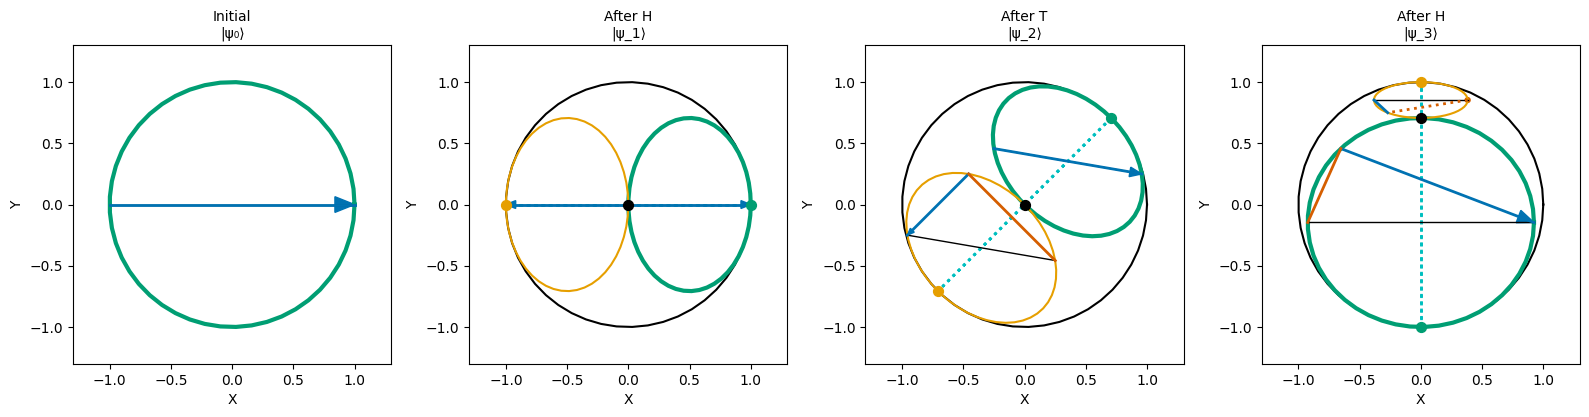


Final state: [0.85355339+0.35355339j 0.14644661-0.35355339j]


In [10]:
def visualize_gate_sequence(initial_spinor, gates, gate_names):
    """
    Visualize a sequence of gates applied to a spinor (2D top view).

    Parameters
    ----------
    initial_spinor : Spinor
        Starting state
    gates : list of np.ndarray
        List of 2x2 gate matrices
    gate_names : list of str
        Names of the gates
    """
    n_gates = len(gates)
    fig, axes = plt.subplots(1, n_gates + 1, figsize=(4 * (n_gates + 1), 4))

    # Track the state
    current = initial_spinor.components.copy()

    # Plot initial state
    plot_spinor_2d(Spinor(current), ax=axes[0])
    axes[0].set_title('Initial\n|ψ₀⟩', fontsize=10)

    # Apply each gate
    for i, (gate, name) in enumerate(zip(gates, gate_names)):
        current = gate @ current
        plot_spinor_2d(Spinor(current), ax=axes[i + 1])
        axes[i + 1].set_title(f'After {name}\n|ψ_{i+1}⟩', fontsize=10)

    plt.tight_layout()
    plt.show()

    return Spinor(current)

# Example: H → T → H sequence (creates a rotation)
print("Gate sequence: H → T → H on |0⟩")
print("This implements a rotation around a diagonal axis.")

spin_up = Spinor.from_angles(0, 0)
gates = [hadamard(), t_gate(), hadamard()]
gate_names = ['H', 'T', 'H']

result = visualize_gate_sequence(spin_up, gates, gate_names)
print(f"\nFinal state: {result.components}")


Demonstrating Y ≈ X·Z·(-i)
Sequence: Z → X on |+⟩


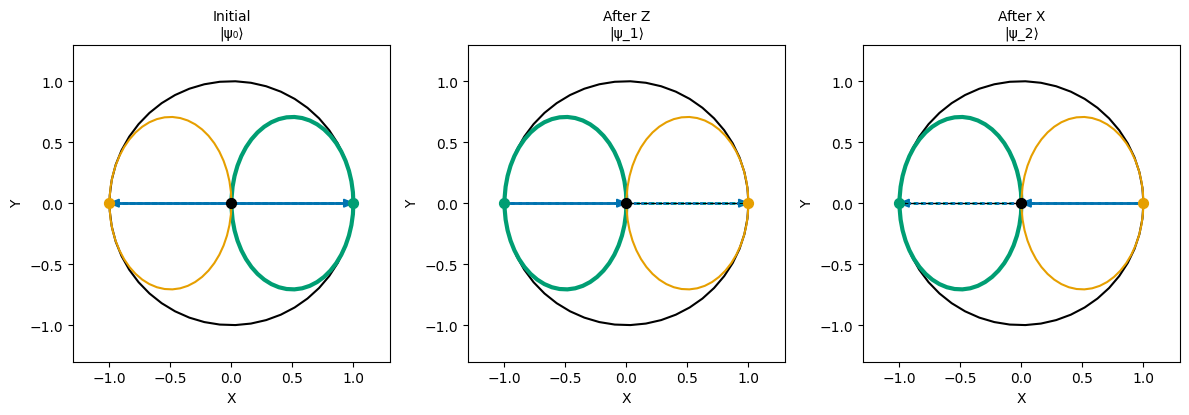


Z→X result: [-0.70710678+0.j  0.70710678+0.j]
Y result:   [0.-0.70710678j 0.+0.70710678j]
Differ by global phase: [-0.-1.j  0.-1.j]


In [11]:
# Another example: Create a Y rotation using X and Z gates
# Y = -i X Z (up to global phase)
print("Demonstrating Y ≈ X·Z·(-i)")
print("Sequence: Z → X on |+⟩")

plus = Spinor(np.array([1, 1], dtype=complex) / np.sqrt(2))
gates_xz = [pauli_z(), pauli_x()]
names_xz = ['Z', 'X']

result_xz = visualize_gate_sequence(plus, gates_xz, names_xz)

# Compare with Y gate directly
y_result = Spinor(pauli_y() @ plus.components)
print(f"\nZ→X result: {result_xz.components}")
print(f"Y result:   {y_result.components}")
print(f"Differ by global phase: {result_xz.components / y_result.components}")


## Summary: Quantum Gates on the Bloch Sphere

Each quantum gate corresponds to a rotation or reflection on the Bloch sphere:

| Gate | Action on Bloch Sphere |
|------|----------------------|
| X | 180° rotation around X-axis |
| Y | 180° rotation around Y-axis |
| Z | 180° rotation around Z-axis |
| H | 180° rotation around (X+Z)/√2 axis |
| S | 90° rotation around Z-axis |
| T | 45° rotation around Z-axis |
| Rx(θ) | θ rotation around X-axis |
| Ry(θ) | θ rotation around Y-axis |
| Rz(θ) | θ rotation around Z-axis |

The hyperchord representation shows how both the magnitude and phase of each spinor component change under these transformations.